<a href="https://colab.research.google.com/github/ndobrylko/ds-learning/blob/main/Projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NLP dla przepisów z social media: klasyfikacja i ekstrakcja struktury**



## 1. Cel projektu
Celem projektu była analiza opisów kulinarnych z social media oraz klasyfikacja tekstów pod kątem tego, czy zawierają użyteczny przepis kulinarny (`usable_recipe`0/1).

Projekt miał na celu sprawdzenie, czy modele NLP i Machine Learning potrafią rozpoznawać wartościowe recipe captions na podstawie treści tekstu.

Dodatkowo projekt zawiera bonusowy moduł ekstrakcji struktury przepisu, którego celem jest próba wyodrębnienia tytułu, składników i kroków przygotowania z captionów oznaczonych jako użyteczne przepisy.

## 2. Dataset
Dataset zawiera 134 captiony kulinarne pochodzące z social media.

Każdy rekord zawierał:
- `caption` – treść posta,
- `usable_recipe` – klasyfikację 0/1 określającą, czy przepis jest użyteczny,
- `quality_score` – ocenę jakości przepisu w skali 1–5.

Dane zostały ręcznie oznaczone.

`usable_recipe` było główną zmienną docelową w modelu klasyfikacyjnym.  
`quality_score` zostało wykorzystane jako dodatkowa informacja o jakości przepisu, pomagająca lepiej zrozumieć dataset podczas analizy eksploracyjnej.

Dzięki `quality_score` można było sprawdzić, czy bardziej kompletne i szczegółowe captiony otrzymują wyższe oceny jakości.

## 3. Zakres projektu
W projekcie wykonano:
- import i podstawową eksplorację danych,
- analizę długości captionów,
- analizę najczęściej występujących słów,
- preprocessing tekstu,
- TF-IDF (nadawanie wag liczbowych słowom w tekstach),
- klasyfikację z użyciem Logistic Regression i Random Forest,
- ocenę modeli przy użyciu precision, recall, F1-score i confusion matrix,
- analizę najważniejszych słów wpływających na klasyfikację,
- bonusowy moduł ekstrakcji struktury przepisu.

In [ ]:
# Import danych - Wczytanie datasetu zawierającego opisy przepisów z social media.
import pandas as pd

df = pd.read_csv("/content/dataset_recipes.csv")

In [ ]:
# Podstawowa eksploracja danych
#sprawdzenie kolumn, polskich znaków, nagłówków:
df.head()
#sprawdzenie rekordów, typów danych, czy są nulle:
df.info()
#sprawdzenie czy są puste pola:
df.isnull().sum()

# Wnioski:
# - Dataset zawiera 134 rekordy i 4 kolumny: id, caption, usable_recipe oraz quality_score.
# - Kolumna caption zawiera dane tekstowe, które będą podstawą analizy NLP.
# - Kolumny usable_recipe i quality_score są numeryczne i mogą zostać wykorzystane jako zmienne docelowe.
# - W żadnej kolumnie nie występują braki danych.
# - Dane zostały poprawnie wczytane i są gotowe do dalszej eksploracji.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             134 non-null    int64 
 1   caption        134 non-null    object
 2   usable_recipe  134 non-null    int64 
 3   quality_score  134 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 4.3+ KB


,0
id,0
caption,0
usable_recipe,0
quality_score,0


In [ ]:
# Sprawdzenie rozkładu zmiennej docelowej usable_recipe
df["usable_recipe"].value_counts()

# Wnioski:
# - Większość captionów to usable_recipe = 1.
# - Dataset jest niezbalansowany, co będzie ważne przy trenowaniu i ocenie modeli.

,count
usable_recipe,
1,116
0,18


In [ ]:
# Sprawdzenie rozkładu ocen jakości przepisów
df["quality_score"].value_counts().sort_index()

# Wnioski:
# - W datasetcie dominują przepisy z quality_score = 5.
# - Rozkład ocen jakości jest nierównomierny.
# -`quality_score` nie był głównym targetem modelu klasyfikacyjnego, ale został wykorzystany do analizy jakości captionów i sprawdzenia, czy długość oraz szczegółowość tekstu są powiązane z oceną przepisu.

,count
quality_score,
1,17
2,15
3,15
4,6
5,81


In [ ]:
# Dodanie długości captionu (liczba znaków)
df["caption_length"] = df["caption"].str.len()

# Podstawowe statystyki długości opisów
df["caption_length"].describe()

# Wnioski:
# - Długość captionów jest mocno zróżnicowana.
# - Średnio caption ma około 930 znaków, ale występują zarówno krótkie, jak i bardzo długie opisy.

,caption_length
count,134.000000
mean,930.201493
std,483.829427
min,137.000000
25%,498.250000
50%,868.500000
75%,1268.500000
max,2154.000000


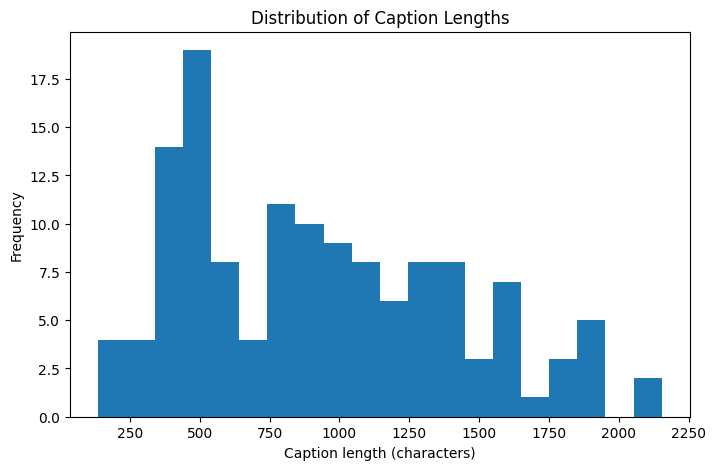

In [ ]:
#Histogram długości captionów
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["caption_length"], bins=20)

plt.xlabel("Caption length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Caption Lengths")

plt.show()

# Wnioski:
# - Długość captionów jest zróżnicowana w całym zbiorze danych.
# - Większość opisów ma średnią długość, jednak występują również bardzo długie captiony.
# - Rozkład jest lekko prawostronnie skośny, co oznacza obecność dłuższych opisów.
# - Długość captionu może wpływać na użyteczność przepisu oraz ocenę jakości.

In [ ]:
# Porównanie średniej długości captionów dla usable_recipe = 0 i usable_recipe = 1
df.groupby("usable_recipe")["caption_length"].mean()

# Wnioski:
# - Captiony oznaczone jako usable_recipe = 1 są średnio znacznie dłuższe.
# - Krótsze opisy częściej nie zawierają wystarczających informacji do uznania przepisu za użyteczny.
# - Długość captionu może być istotną cechą w modelu klasyfikacyjnym NLP.

,caption_length
usable_recipe,
0,455.388889
1,1003.879310


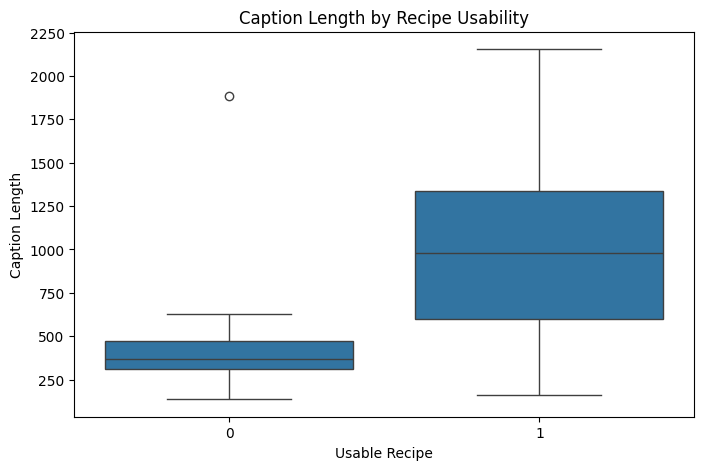

In [ ]:
# Wizualizacja długości captionów w zależności od usable_recipe
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="usable_recipe",
    y="caption_length",
    data=df
)

plt.xlabel("Usable Recipe")
plt.ylabel("Caption Length")
plt.title("Caption Length by Recipe Usability")

plt.show()

# Wnioski:
# - Captiony oznaczone jako usable_recipe = 1 są wyraźnie dłuższe niż captiony klasy 0.
# - Mediana długości captionów dla usable recipes jest znacznie wyższa.
# - Klasa usable_recipe = 1 charakteryzuje się większym zróżnicowaniem długości tekstów.
# - Krótsze captiony częściej należą do klasy nieużytecznych przepisów.
# - Długość tekstu może być istotną cechą predykcyjną w modelach NLP.

In [ ]:
# Analiza średniej długości captionów dla poszczególnych quality_score
df.groupby("quality_score")["caption_length"].mean()

# Wnioski:
# - Średnia długość captionów rośnie wraz z quality_score.
# - Przepisy o wyższej jakości zawierają zazwyczaj bardziej rozbudowane opisy.
# - Captiony z quality_score = 5 są średnio najdłuższe.
# - Długość tekstu może być powiązana z kompletnością i jakością przepisu.

,caption_length
quality_score,
1,463.352941
2,444.600000
3,602.200000
4,767.666667
5,1190.888889


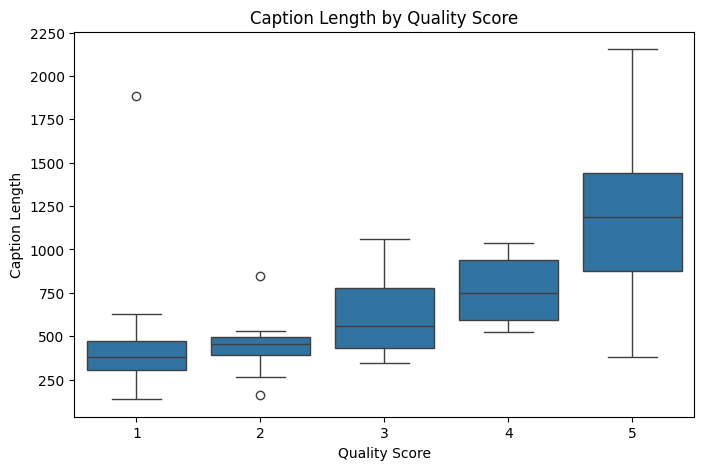

In [ ]:
# Wizualizacja długości captionów względem quality_score
plt.figure(figsize=(8,5))

sns.boxplot(
    x="quality_score",
    y="caption_length",
    data=df
)

plt.xlabel("Quality Score")
plt.ylabel("Caption Length")
plt.title("Caption Length by Quality Score")

plt.show()

# Wnioski:
# - Długość captionów wzrasta wraz z jakością przepisu.
# - Przepisy z quality_score = 5 zawierają najbardziej rozbudowane opisy.
# - Wyższe quality_score wiąże się z większą zmiennością długości tekstów.
# - Krótsze captiony częściej otrzymują niższe oceny jakości.
# - Wyniki sugerują, że bardziej szczegółowe opisy są oceniane jako lepsze jakościowo.

In [ ]:
# Dodanie liczby słów w captionach
df["word_count"] = df["caption"].apply(lambda x: len(str(x).split()))

# Podstawowe statystyki liczby słów
df["word_count"].describe()

# Wnioski:
# - Captiony zawierają średnio około 133 słów.
# - W zbiorze występują zarówno krótkie, jak i bardzo rozbudowane opisy.
# - Duże zróżnicowanie liczby słów może wpływać na wyniki modeli NLP.
# - Dłuższe captiony prawdopodobnie zawierają bardziej szczegółowe informacje o przepisie.

,word_count
count,134.000000
mean,132.873134
std,72.064969
min,18.000000
25%,71.250000
50%,128.000000
75%,178.500000
max,324.000000


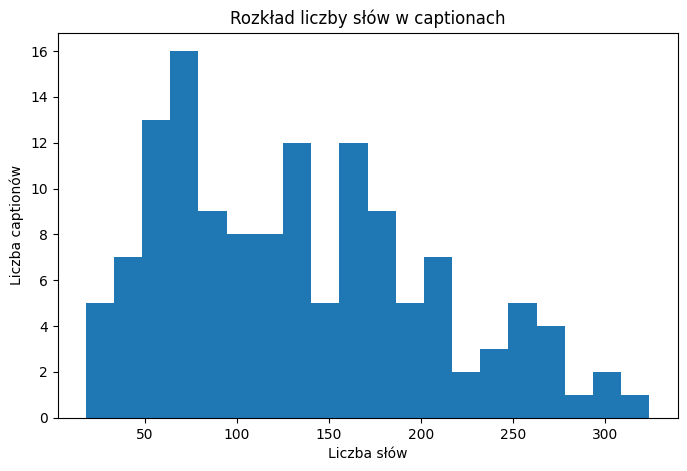

In [ ]:
# Wizualizacja rozkładu liczby słów w captionach
plt.figure(figsize=(8,5))

plt.hist(df["word_count"], bins=20)

plt.xlabel("Liczba słów")
plt.ylabel("Liczba captionów")
plt.title("Rozkład liczby słów w captionach")

plt.show()

# Wnioski:
# - Większość captionów zawiera od około 50 do 200 słów.
# - Rozkład liczby słów jest prawostronnie skośny.
# - W zbiorze występują pojedyncze bardzo długie captiony.
# - Captiony różnią się poziomem szczegółowości i ilością informacji.
# - Liczba słów może być istotną cechą przy klasyfikacji jakości przepisów.

In [ ]:
# Połączenie wszystkich captionów w jeden tekst
all_text = " ".join(df["caption"].astype(str))

# Podział na słowa
words = all_text.split()

# Najczęściej występujące słowa
from collections import Counter

word_freq = Counter(words)

word_freq.most_common(20)

# Wnioski:
# - Najczęściej występujące słowa obejmują głównie stopwords oraz znaki charakterystyczne dla social media.
# - W danych występują emoji, symbole oraz jednostki kulinarne, np. "g" czy "łyżki".
# - Captiony zawierają zarówno elementy instrukcji, jak i składników przepisów.
# - Wyniki wskazują na potrzebę preprocessing'u tekstu przed dalszą analizą NLP.
# - W projekcie należy zachować informacje istotne dla przepisów, takie jak liczby i jednostki miary.

[('i', 558),
 ('na', 398),
 ('z', 367),
 ('w', 280),
 ('do', 244),
 ('-', 203),
 ('1', 160),
 ('2', 102),
 ('lub', 76),
 ('g', 76),
 ('się', 70),
 ('.', 68),
 ('łyżki', 64),
 ('to', 56),
 ('•', 56),
 ('nie', 55),
 ('⬛️', 53),
 ('przez', 51),
 ('łyżeczki', 47),
 ('a', 46)]

In [ ]:
# Import bibliotek do preprocessing'u tekstu
import re
import string

# Funkcja czyszcząca tekst z zachowaniem informacji ważnych dla przepisów
def clean_text(text):

    # Zamiana tekstu na małe litery
    text = text.lower()

    # Usunięcie emoji
    text = re.sub(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "]+",
        "",
        text
    )

    # Usunięcie interpunkcji
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Usunięcie nadmiarowych spacji
    text = re.sub(r"\s+", " ", text).strip()

    # Zwrócenie oczyszczonego tekstu
    return text

In [ ]:
# Zastosowanie funkcji czyszczącej do captionów
df["clean_caption"] = df["caption"].apply(clean_text)

# Podgląd oryginalnych i oczyszczonych captionów
df[["caption", "clean_caption"]].head()

# Wnioski:
# - Captiony zostały ujednolicone poprzez zamianę tekstu na małe litery.
# - Usunięto większość emoji oraz znaków interpunkcyjnych.
# - Zachowano liczby i jednostki istotne dla przepisów kulinarnych.
# - Oczyszczony tekst jest bardziej uporządkowany i gotowy do dalszej analizy NLP.

,caption,clean_caption
0,PRZEPIS👇 Składniki: 500g piersi z kurczaka + 1...,przepis składniki 500g piersi z kurczaka 1 łyż...
1,Fileciki zapiekane z majonezem pesto🥰🌿 Wasz no...,fileciki zapiekane z majonezem pesto🥰 wasz now...
2,Składniki tej sałatki mogą wydawać się nieoczy...,składniki tej sałatki mogą wydawać się nieoczy...
3,"ZUPA Z KURCZAKIEM 🍲\n\nIdealna na szybki, domo...",zupa z kurczakiem idealna na szybki domowy obi...
4,💬daj znać czy będziesz robić ? 😋\n\n… KANAPKI ...,daj znać czy będziesz robić … kanapki bez chle...


In [ ]:
# Połączenie oczyszczonych captionów w jeden tekst
clean_all_text = " ".join(df["clean_caption"].astype(str))

# Podział tekstu na słowa
clean_words = clean_all_text.split()

# Liczenie najczęściej występujących słów
clean_word_freq = Counter(clean_words)

# 20 najczęściej występujących słów
clean_word_freq.most_common(20)

# Wnioski:
# - Po preprocessing'u tekst stał się bardziej uporządkowany.
# - Usunięto większość znaków specjalnych oraz części szumu tekstowego.
# - Najczęściej występujące słowa są związane z gotowaniem i składnikami przepisów.
# - W danych nadal występują stopwords, które mogą zostać usunięte w kolejnym etapie preprocessing'u.
# - Wyniki potwierdzają, że dataset zawiera wiele cech charakterystycznych dla przepisów kulinarnych.

[('i', 594),
 ('na', 444),
 ('z', 388),
 ('w', 313),
 ('do', 262),
 ('1', 180),
 ('2', 118),
 ('g', 84),
 ('lub', 80),
 ('przepis', 75),
 ('się', 73),
 ('to', 73),
 ('składniki', 67),
 ('sól', 67),
 ('łyżki', 67),
 ('ok', 66),
 ('nie', 65),
 ('pieprz', 63),
 ('a', 61),
 ('minut', 58)]

In [ ]:
# Import wektoryzatora TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Utworzenie wektoryzatora TF-IDF
tfidf = TfidfVectorizer()

# Zamiana oczyszczonych captionów na macierz TF-IDF
X = tfidf.fit_transform(df["clean_caption"])

# Wyświetlenie rozmiaru macierzy TF-IDF
X.shape

# Wnioski:
# - Captiony zostały przekształcone do postaci numerycznej przy użyciu TF-IDF.
# - Model wykrył 4907 unikalnych tokenów w datasetcie.
# - Każdy caption został reprezentowany jako wektor cech tekstowych.
# - TF-IDF zmniejsza wpływ bardzo częstych słów i podkreśla bardziej charakterystyczne tokeny.

(134, 4907)

In [ ]:
# Zmienna target dla klasyfikacji usable_recipe
y = df["usable_recipe"]

# Podgląd rozmiaru targetu
y.shape

(134,)

In [ ]:
# Podział danych na zbiór treningowy i testowy
from sklearn.model_selection import train_test_split

# Podział X i y na dane treningowe oraz testowe
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Sprawdzenie rozmiarów zbiorów
X_train.shape, X_test.shape, y_train.shape, y_test.shape

# Wnioski:
# - Dataset został podzielony na zbiór treningowy i testowy.
# - 80% danych wykorzystano do treningu modelu, a 20% do testowania.
# - Zastosowano stratified split, aby zachować proporcje klas usable_recipe.
# - Podział umożliwia ocenę skuteczności modelu na niewidzianych danych.

((107, 4907), (27, 4907), (107,), (27,))

In [ ]:
# Import modelu Logistic Regression
from sklearn.linear_model import LogisticRegression

# Utworzenie modelu
lr_model = LogisticRegression()

# Trenowanie modelu
lr_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Predykcje modelu na zbiorze testowym
y_pred = lr_model.predict(X_test)

# Podgląd pierwszych predykcji
y_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
# Import metryk klasyfikacji
from sklearn.metrics import classification_report

# Raport klasyfikacji modelu
print(classification_report(y_test, y_pred))

# Wnioski:
# - Model osiągnął wysoką accuracy, jednak wyniki są zaburzone przez niezbalansowany dataset.
# - Logistic Regression przewidywał głównie klasę usable_recipe = 1.
# - Model nie wykrył poprawnie żadnego przypadku klasy 0.
# - Accuracy nie jest wystarczającą metryką dla niezbalansowanych danych.
# - F1-score oraz recall są bardziej odpowiednie do oceny modelu w tym projekcie.

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.85      1.00      0.92        23

    accuracy                           0.85        27
   macro avg       0.43      0.50      0.46        27
weighted avg       0.73      0.85      0.78        27



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Utworzenie Logistic Regression z balansem klas - klasa 0 jest rzadsza, powinniśmy ją traktować jako ważniejszą podczas uczenia.
lr_model_balanced = LogisticRegression(class_weight="balanced")

# Trenowanie modelu
lr_model_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
# Predykcje modelu z balansem klas
y_pred_balanced = lr_model_balanced.predict(X_test)

# Raport klasyfikacji dla zbalansowanego modelu
print(classification_report(y_test, y_pred_balanced))

# Wnioski:
# - Zastosowanie class_weight="balanced" poprawiło wykrywanie klasy mniejszościowej.
# - Model zaczął poprawnie klasyfikować część przypadków usable_recipe = 0.
# - Wyniki dla klasy 1 nadal pozostają bardzo dobre.
# - Balanced Logistic Regression lepiej radzi sobie z niezbalansowanym datasetem.
# - Recall dla klasy 0 nadal jest niski, co może wynikać z małej liczby przykładów tej klasy.

              precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.88      1.00      0.94        23

    accuracy                           0.89        27
   macro avg       0.94      0.62      0.67        27
weighted avg       0.90      0.89      0.86        27



In [ ]:
# Import modelu Random Forest
from sklearn.ensemble import RandomForestClassifier

# Utworzenie modelu Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Trenowanie modelu
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
# Predykcje Random Forest na zbiorze testowym
y_pred_rf = rf_model.predict(X_test)

# Raport klasyfikacji dla Random Forest
print(classification_report(y_test, y_pred_rf))

# Wnioski:
# - Random Forest osiągnął bardzo podobne wyniki do Logistic Regression.
# - Oba modele dobrze klasyfikują usable_recipe = 1.
# - Klasa 0 nadal pozostaje trudna do wykrycia ze względu na niezbalansowany dataset.
# - Bardziej złożony model nie przyniósł wyraźnej poprawy wyników.
# - Logistic Regression okazał się skutecznym baseline'em dla problemu NLP.

              precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.88      1.00      0.94        23

    accuracy                           0.89        27
   macro avg       0.94      0.62      0.67        27
weighted avg       0.90      0.89      0.86        27



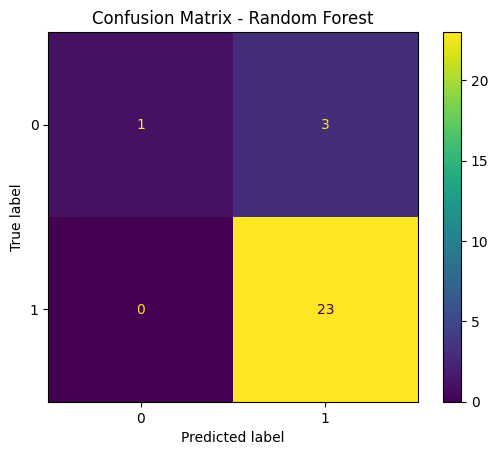

In [ ]:
# Import funkcji do wizualizacji confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Utworzenie confusion matrix dla Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

# Wizualizacja confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix - Random Forest")

plt.show()

# Wnioski:
# - Model poprawnie sklasyfikował 23 przypadki usable_recipe = 1.
# - Model poprawnie wykrył 1 przypadek klasy usable_recipe = 0.
# - 3 przypadki klasy 0 zostały błędnie zaklasyfikowane jako usable_recipe = 1.
# - Model nie popełnił błędów typu false negative dla klasy 1.(nie przewidział 0 dla klasy 1)
# - Random Forest ma tendencję do przewidywania klasy większościowej.
# - Wyniki potwierdzają problem niezbalansowanego datasetu.
# - Confusion Matrix ułatwia analizę typów błędów popełnianych przez model.

# Dodatkowa interpretacja:
# - Model nie odrzucił żadnego poprawnego usable recipe.
# - Większość błędów polegała na zaakceptowaniu słabszych przepisów jako usable.
# - Model wykazuje większą skłonność do klasyfikowania captionów jako usable_recipe = 1.

In [ ]:
# Pobranie nazw cech (słów) z TF-IDF
feature_names = tfidf.get_feature_names_out()

# Pobranie współczynników modelu Logistic Regression
coefficients = lr_model_balanced.coef_[0]

# Utworzenie DataFrame z cechami i ich wagami
feature_importance = pd.DataFrame({
    "word": feature_names,
    "coefficient": coefficients
})

# Sortowanie słów najbardziej związanych z usable_recipe = 1
top_positive_words = feature_importance.sort_values(
    by="coefficient",
    ascending=False
)

# 20 najważniejszych słów dla klasy usable_recipe = 1
top_positive_words.head(20)

# Wnioski:
# - Model Logistic Regression nauczył się rozpoznawać słowa charakterystyczne dla przepisów kulinarnych.
# - Najbardziej wpływowe tokeny obejmują składniki, jednostki miary oraz instrukcje przygotowania.
# - Słowa takie jak "sól", "pieprz", "łyżki" czy "dodajemy" silnie wskazują na usable recipes.
# - Wyniki potwierdzają, że preprocessing zachował istotne informacje kulinarne.
# - Analiza cech pokazuje, że model nauczył się rzeczywistych wzorców występujących w przepisach.

,word,coefficient
3843,sól,0.389463
2644,pieprz,0.371955
4817,łyżki,0.353903
4807,łyżeczka,0.353248
4809,łyżeczki,0.333111
15,12,0.323440
3546,składniki,0.318812
2096,na,0.312871
716,do,0.305544
1680,kurczaka,0.298878


In [ ]:
# Słowa najbardziej związane z usable_recipe = 0
top_negative_words = feature_importance.sort_values(
    by="coefficient",
    ascending=True
)

# 20 najważniejszych słów dla klasy usable_recipe = 0
top_negative_words.head(20)

# Wnioski:
# - Słowa związane z usable_recipe = 0 mają częściej charakter marketingowy lub promocyjny.
# - Model rozpoznaje captiony mniej przypominające klasyczne przepisy kulinarne.
# - Tokeny takie jak "promocji", "post" czy "menu" częściej występują w mniej użytecznych captionach.
# - Wyniki sugerują, że model potrafi odróżniać treści instruktażowe od bardziej reklamowych postów.
# - Analiza cech potwierdza skuteczność TF-IDF w wykrywaniu charakterystycznych wzorców językowych.

,word,coefficient
1127,gotujzcukiereczkiem,-0.590123
4793,łazanki,-0.566246
4370,wypełnij,-0.503429
3889,talerza,-0.503429
4707,znajdziesz,-0.494936
419,cały,-0.494444
3622,sorbet,-0.470087
1839,marca,-0.468968
2124,najlepsze,-0.458558
2909,post,-0.416497


# Podsumowanie

- Projekt dotyczył klasyfikacji captionów kulinarnych z social media.
- Celem było przewidywanie, czy caption zawiera usable recipe.
- W projekcie zastosowano preprocessing tekstu oraz TF-IDF (nadawanie wag liczbowych słowom w tekstach).
- Przeanalizowano długość captionów oraz najczęściej występujące słowa.
- Logistic Regression i Random Forest osiągnęły podobne wyniki.
- Modele dobrze rozpoznawały usable recipes, ale miały trudności z klasą mniejszościową.
- Najbardziej wpływowe słowa obejmowały składniki, jednostki miary i instrukcje kulinarne.
- Dataset był niezbalansowany, co wpłynęło na recall klasy 0.
- Projekt pokazał, że NLP może skutecznie analizować recipe captions z social media.

# Bonus: Ekstrakcja struktury przepisu (Recipe Structure Extraction)

## 1. Cel modułu

Celem dodatkowego modułu było automatyczne wyodrębnianie:
- tytułu przepisu,
- składników,
- kroków przygotowania

z captionów kulinarnych pochodzących z social media.

## 2. Założenie modułu

Moduł ekstrakcji struktury przepisu został zastosowany tylko do captionów oznaczonych jako `usable_recipe = 1`.

Wynika to z tego, że ekstrakcja tytułu, składników i kroków przygotowania ma sens tylko dla tekstów, które faktycznie zawierają użyteczny przepis.

In [ ]:
# Utworzenie osobnego DataFrame tylko dla usable recipes
df_usable = df[df["usable_recipe"] == 1].copy()

# Sprawdzenie liczby rekordów w module parsera
df_usable.shape

# Wnioski:
# - Do modułu ekstrakcji struktury przepisu wybrano tylko rekordy oznaczone jako usable_recipe = 1.
# - Parser będzie działał na 116 captionach zawierających użyteczne przepisy.
# - Takie podejście ogranicza analizę do tekstów, dla których ekstrakcja składników i kroków przygotowania ma sens.

(116, 7)

In [ ]:
# Funkcje do ekstrakcji składników z usable recipes

import re

# Wzorce charakterystyczne dla składników i ilości bez warningu
ingredient_pattern = (
    r"\b\d+[\d\/.,]*\s*(?:g|kg|ml|l)?\s+\w+"
    r"|\b\d+[\d\/.,]*\s*(?:łyżka|łyżki|łyżek|łyżeczka|łyżeczki|łyżeczek|szklanka|szklanki|szklanek)\s+\w+"
    r"|\b(?:pół|pol|pól)\s+(?:łyżki|łyżeczki|szklanki|kg|g|l|ml)\s+\w+"
    r"|\b(?:łyżka|łyżki|łyżeczka|łyżeczki|szklanka|szklanki)\s+\w+"
    r"|\bsól\b|\bpieprz\b"
)

# Funkcja wyodrębniająca sekcję składników po nagłówku "Składniki:"
def extract_ingredients_section(text):

    # Zamiana tekstu na małe litery dla łatwiejszego wyszukiwania
    text_lower = text.lower()

    # Sprawdzenie, czy caption zawiera wyraźny nagłówek "składniki:"
    if "składniki:" in text_lower:

        # Pobranie tekstu po nagłówku "składniki:"
        ingredients_section = text_lower.split("składniki:", 1)[1].strip()

        # Zwrócenie wyodrębnionej sekcji składników
        return ingredients_section

    # Jeśli nie znaleziono nagłówka, zwróć None
    return None


# Funkcja dzieląca sekcję składników na pojedyncze elementy
def split_ingredients(ingredients_text):

    # Jeśli nie wykryto sekcji składników, zwróć None
    if ingredients_text is None:
        return None

    # Podział składników po nowych liniach
    ingredients = ingredients_text.split("\n")

    # Usunięcie pustych elementów i nadmiarowych spacji
    ingredients = [item.strip() for item in ingredients if item.strip() != ""]

    # Zwrócenie listy składników
    return ingredients

In [ ]:
# Zastosowanie parsera składników do usable recipes
df_usable["ingredients_section"] = df_usable["caption"].apply(extract_ingredients_section)
df_usable["ingredients_list"] = df_usable["ingredients_section"].apply(split_ingredients)

# Sprawdzenie, czy usable recipe zawiera wzorce typowe dla składników
df_usable["has_ingredient_pattern"] = df_usable["clean_caption"].str.contains(
    ingredient_pattern,
    case=False,
    na=False,
    regex=True
)

# Podgląd wyników ekstrakcji składników
df_usable[["caption", "ingredients_section", "ingredients_list", "has_ingredient_pattern"]].head(5)

# Wnioski:
# - Parser został zastosowany tylko do captionów oznaczonych jako usable_recipe = 1.
# - Część użytecznych przepisów posiada wyraźną sekcję "Składniki:", którą można wyodrębnić.
# - Dla captionów bez formalnej sekcji składników kolumna has_ingredient_pattern wykrywa potencjalne informacje składnikowe.
# - Podejście hybrydowe łączy ekstrakcję sekcji składników z wykrywaniem wzorców ilości i jednostek.

,caption,ingredients_section,ingredients_list,has_ingredient_pattern
0,PRZEPIS👇 Składniki: 500g piersi z kurczaka + 1...,500g piersi z kurczaka + 1 łyżeczka przyprawy ...,[500g piersi z kurczaka + 1 łyżeczka przyprawy...,True
1,Fileciki zapiekane z majonezem pesto🥰🌿 Wasz no...,None,None,True
3,"ZUPA Z KURCZAKIEM 🍲\n\nIdealna na szybki, domo...",obrane mięso z rosołu\nkilka ziemniaków\n1 mar...,"[obrane mięso z rosołu, kilka ziemniaków, 1 ma...",True
4,💬daj znać czy będziesz robić ? 😋\n\n… KANAPKI ...,None,None,True
5,Co za zupa😍 pieczarkowa z tortellini I kurczak...,None,None,True


In [ ]:
# Podsumowanie wykrytych sekcji składników i wzorców składnikowych w usable recipes
print("Liczba usable recipes z wyraźną sekcją składników:")
print(df_usable["ingredients_section"].notnull().sum())

print("\nLiczba usable recipes zawierających wzorce składnikowe:")
print(df_usable["has_ingredient_pattern"].value_counts())

# Wnioski:
# - 30 usable recipes zawiera wyraźną sekcję "Składniki:".
# - Wszystkie 116 usable recipes zawierają co najmniej jeden wzorzec składnikowy.
# - Oznacza to, że użyteczne przepisy zwykle zawierają informacje o składnikach lub ilościach.
# - Wzorzec składnikowy jest szeroki, dlatego dobrze sprawdza obecność informacji składnikowych, ale nie wyodrębnia jeszcze pełnej listy składników.
# - Formalna ekstrakcja listy składników jest możliwa głównie dla captionów z wyraźną sekcją "Składniki:".

Liczba usable recipes z wyraźną sekcją składników:
30

Liczba usable recipes zawierających wzorce składnikowe:
has_ingredient_pattern
True    116
Name: count, dtype: int64


In [ ]:
# Funkcja wyodrębniająca potencjalny tytuł przepisu
def extract_recipe_title(text):

    # Podział captionu na linie
    lines = text.split("\n")

    # Usunięcie pustych linii i nadmiarowych spacji
    lines = [line.strip() for line in lines if line.strip() != ""]

    # Jeśli caption nie zawiera żadnej linii, zwróć None
    if len(lines) == 0:
        return None

    # Lista fraz, które zwykle nie są tytułem przepisu
    excluded_starts = [
        "przepis",
        "daj znać",
        "co na",
        "bardzo",
        "wasz",
        "idealna",
        "idealne"
    ]

    # Przejście po kolejnych liniach i wybranie pierwszej sensownej jako tytułu
    for line in lines:

        line_lower = line.lower()

        # Pominięcie linii zaczynających się od ogólnych CTA/opisów
        if any(line_lower.startswith(phrase) for phrase in excluded_starts):
            continue

        # Zwrócenie pierwszej sensownej linii jako tytułu
        return line

    # Jeśli nie znaleziono sensownego tytułu, zwróć None
    return None

In [ ]:
# Ponowne zastosowanie ulepszonej funkcji ekstrakcji tytułu
df_usable["recipe_title"] = df_usable["caption"].apply(extract_recipe_title)

# Podgląd wyodrębnionych tytułów
df_usable[["caption", "recipe_title"]].head(10)

# Wnioski:
# - Ulepszona funkcja lepiej radzi sobie z pomijaniem części ogólnych opisów i CTA (Call To Action jak zapisz ten post,daj znać w komentarzu itd).
# - Parser poprawnie wykrywa tytuły w uporządkowanych captionach, np. "ZUPA Z KURCZAKIEM" czy "OMLET SZARLOTKA".
# - W części przypadków pierwsze sensowne zdanie nadal nie jest właściwym tytułem przepisu.
# - Ekstrakcja tytułu z captionów social media jest trudna, ponieważ posty często zaczynają się od CTA, opisu lub treści marketingowej.
# - Moduł ekstrakcji tytułu należy traktować jako prosty proof of concept - wstępny prototyp pokazujący, że dany pomysł może działać..

,caption,recipe_title
0,PRZEPIS👇 Składniki: 500g piersi z kurczaka + 1...,None
1,Fileciki zapiekane z majonezem pesto🥰🌿 Wasz no...,Fileciki zapiekane z majonezem pesto🥰🌿 Wasz no...
3,"ZUPA Z KURCZAKIEM 🍲\n\nIdealna na szybki, domo...",ZUPA Z KURCZAKIEM 🍲
4,💬daj znać czy będziesz robić ? 😋\n\n… KANAPKI ...,💬daj znać czy będziesz robić ? 😋
5,Co za zupa😍 pieczarkowa z tortellini I kurczak...,Co za zupa😍 pieczarkowa z tortellini I kurczak...
6,"Kotleciki galicyjskie, dzisiaj zjedzone z dokł...","Kotleciki galicyjskie, dzisiaj zjedzone z dokł..."
7,"Bardzo zwracam uwagę na to, co jedzą moje dzie...",Zapach domowego chleba to dla mnie coś więcej ...
8,Co na płaski brzuch 🔥 🩱 Talia osy i płaski brz...,Brzuch jak balon? Ciężko po kolacji? Zatrzyman...
10,Warzywna porcja witamin 🥦 6m+👶🏻\n\n🛒 Lista zak...,Warzywna porcja witamin 🥦 6m+👶🏻
11,OMLET SZARLOTKA 🍎\n\nSkładniki:\n- 1 jajko\n- ...,OMLET SZARLOTKA 🍎


In [ ]:
# Funkcja wyodrębniająca sekcję przygotowania przepisu
def extract_preparation_section(text):

    # Zamiana tekstu na małe litery dla łatwiejszego wyszukiwania
    text_lower = text.lower()

    # Lista możliwych nagłówków sekcji przygotowania
    preparation_headers = [
        "przygotowanie:",
        "wykonanie:",
        "sposób przygotowania:",
        "instrukcja:",
        "jak zrobić:"
    ]

    # Sprawdzenie, czy któryś nagłówek występuje w captionie
    for header in preparation_headers:
        if header in text_lower:

            # Pobranie tekstu po znalezionym nagłówku
            preparation_section = text_lower.split(header, 1)[1].strip()

            # Zwrócenie wyodrębnionej sekcji przygotowania
            return preparation_section

    # Jeśli nie znaleziono sekcji przygotowania, zwróć None
    return None

In [ ]:
# Zastosowanie parsera przygotowania do usable recipes
df_usable["preparation_section"] = df_usable["caption"].apply(extract_preparation_section)

# Podgląd wyodrębnionych sekcji przygotowania
df_usable[["caption", "preparation_section"]].head(10)

# Wnioski:
# - Parser potrafi wyodrębnić sekcję przygotowania, jeśli caption zawiera wyraźny nagłówek.
# - Część usable recipes nie posiada formalnej sekcji przygotowania, dlatego zwracana jest wartość None.
# - Wyodrębnione fragmenty często zawierają instrukcje kulinarne, np. czasowniki typu "dodaj", "podsmaż", "gotuj".
# - Ekstrakcja kroków przygotowania jest łatwiejsza dla uporządkowanych captionów.
# - Nieregularny format social media captionów ogranicza skuteczność prostego parsera regułowego.

,caption,preparation_section
0,PRZEPIS👇 Składniki: 500g piersi z kurczaka + 1...,None
1,Fileciki zapiekane z majonezem pesto🥰🌿 Wasz no...,piersi z kurczaka rozkroić w poprzek na 2 częś...
3,"ZUPA Z KURCZAKIEM 🍲\n\nIdealna na szybki, domo...","na maśle podsmaż pokrojonego pora, dodaj start..."
4,💬daj znać czy będziesz robić ? 😋\n\n… KANAPKI ...,None
5,Co za zupa😍 pieczarkowa z tortellini I kurczak...,None
6,"Kotleciki galicyjskie, dzisiaj zjedzone z dokł...",w misie kajzerkę zalać mlekiem i zostawić aż n...
7,"Bardzo zwracam uwagę na to, co jedzą moje dzie...",None
8,Co na płaski brzuch 🔥 🩱 Talia osy i płaski brz...,"1. jajka ugotuj na twardo, przestudź i pokrój ..."
10,Warzywna porcja witamin 🥦 6m+👶🏻\n\n🛒 Lista zak...,obranego ziemniaka drobno siekam i gotuję do m...
11,OMLET SZARLOTKA 🍎\n\nSkładniki:\n- 1 jajko\n- ...,None


In [ ]:
# Podsumowanie liczby usable recipes z wykrytą sekcją przygotowania
df_usable["preparation_section"].notnull().value_counts()

# Wnioski:
# - Parser wykrył sekcję przygotowania w 22 usable recipes.
# - Większość użytecznych przepisów nie posiada formalnego nagłówka przygotowania.
# - Brak wykrytej sekcji nie oznacza braku instrukcji, ponieważ kroki mogą być zapisane bez wyraźnego nagłówka.
# - Prosty parser regułowy działa najlepiej dla uporządkowanych captionów.
# - W przyszłości ekstrakcję kroków można rozszerzyć o wykrywanie czasowników kulinarnych, takich jak "dodaj", "wymieszaj", "gotuj", "piecz" czy "smaż".

,count
preparation_section,
False,94
True,22


In [ ]:
# Wykrywanie czasowników charakterystycznych dla kroków przygotowania
preparation_verb_pattern = (
    r"\bdodaj\b|\bdodajemy\b|\bwymieszaj\b|\bwymieszamy\b|\bwymieszać\b"
    r"|\bsmaż\b|\bsmażymy\b|\busmaż\b|\bgotuj\b|\bgotujemy\b|\bugotuj\b"
    r"|\bpiecz\b|\bpieczemy\b|\bupiecz\b|\bkroimy\b|\bpokrój\b|\bpokroić\b"
    r"|\bpodsmaż\b|\bpodsmażamy\b|\bblenduj\b|\bzblenduj\b|\bprzełóż\b"
)

# Sprawdzenie, czy usable recipe zawiera czasowniki przygotowania
df_usable["has_preparation_verbs"] = df_usable["clean_caption"].str.contains(
    preparation_verb_pattern,
    case=False,
    na=False,
    regex=True
)

# Liczba usable recipes zawierających czasowniki przygotowania
df_usable["has_preparation_verbs"].value_counts()

# Wnioski:
# - 72 usable recipes zawierają czasowniki charakterystyczne dla przygotowania potraw.
# - Liczba ta jest znacznie wyższa niż liczba captionów z formalną sekcją przygotowania.
# - Oznacza to, że wiele przepisów zawiera instrukcje, mimo że nie posiada nagłówka "Przygotowanie:".
# - Wykrywanie czasowników kulinarnych pozwala lepiej identyfikować kroki przygotowania w nieregularnych captionach.
# - Podejście oparte na nagłówkach i czasownikach lepiej pasuje do danych z social media.

,count
has_preparation_verbs,
True,72
False,44


In [ ]:
# Funkcja wyodrębniająca potencjalne kroki przygotowania
def extract_preparation_steps(text):

    # Zamiana tekstu na małe litery
    text_lower = text.lower()

    # Podział tekstu na fragmenty po kropkach, nowych liniach i średnikach
    steps = re.split(r"\.|\n|;", text_lower)

    # Lista czasowników charakterystycznych dla przygotowania
    cooking_verbs = [
        "dodaj", "dodajemy", "wymieszaj", "wymieszamy", "wymieszać",
        "smaż", "smażymy", "usmaż", "gotuj", "gotujemy", "ugotuj",
        "piecz", "pieczemy", "upiecz", "kroimy", "pokrój", "pokroić",
        "podsmaż", "podsmażamy", "blenduj", "zblenduj", "przełóż",
        "dopraw", "doprawiamy", "odstaw", "wlej", "wrzuć", "posiekaj"
    ]

    # Zostawienie tylko fragmentów zawierających czasowniki kulinarne
    preparation_steps = [
        step.strip()
        for step in steps
        if any(verb in step for verb in cooking_verbs) and len(step.strip()) > 5
    ]

    # Jeśli nie znaleziono kroków, zwróć None
    if len(preparation_steps) == 0:
        return None

    # Zwrócenie listy potencjalnych kroków przygotowania
    return preparation_steps

In [ ]:
# Zastosowanie funkcji ekstrakcji kroków przygotowania do usable recipes
df_usable["preparation_steps"] = df_usable["caption"].apply(extract_preparation_steps)

# Podgląd wyodrębnionych kroków przygotowania
df_usable[["caption", "preparation_steps"]].head(10)

# Wnioski:
# - Funkcja potrafi wyodrębnić potencjalne kroki przygotowania na podstawie czasowników kulinarnych.
# - Parser dobrze działa dla fragmentów zawierających instrukcje typu "dodaj", "podsmaż", "ugotuj" czy "pokrój".
# - Występują również fałszywe trafienia, gdy fragment zawiera słowo związane z gotowaniem, ale nie jest właściwym krokiem.
# - Nieregularny format captionów z social media utrudnia precyzyjną ekstrakcję kroków przygotowania.
# - Moduł kroków przygotowania należy traktować jako proof of concept.

,caption,preparation_steps
0,PRZEPIS👇 Składniki: 500g piersi z kurczaka + 1...,None
1,Fileciki zapiekane z majonezem pesto🥰🌿 Wasz no...,None
3,"ZUPA Z KURCZAKIEM 🍲\n\nIdealna na szybki, domo...","[na maśle podsmaż pokrojonego pora, dodaj star..."
4,💬daj znać czy będziesz robić ? 😋\n\n… KANAPKI ...,None
5,Co za zupa😍 pieczarkowa z tortellini I kurczak...,[co za zupa😍 pieczarkowa z tortellini i kurcza...
6,"Kotleciki galicyjskie, dzisiaj zjedzone z dokł...","[masło klarowane do smażenia, w kolejnej misie..."
7,"Bardzo zwracam uwagę na to, co jedzą moje dzie...","[chcę, żeby kiedyś, jako dorośli, ten zapach k..."
8,Co na płaski brzuch 🔥 🩱 Talia osy i płaski brz...,"[jajka ugotuj na twardo, przestudź i pokrój w ..."
10,Warzywna porcja witamin 🥦 6m+👶🏻\n\n🛒 Lista zak...,[obranego ziemniaka drobno siekam i gotuję do ...
11,OMLET SZARLOTKA 🍎\n\nSkładniki:\n- 1 jajko\n- ...,"[dodajemy żółtko i mąkę i mieszamy, na koniec ..."


In [ ]:
# Podsumowanie liczby usable recipes z wykrytymi krokami przygotowania
df_usable["preparation_steps"].notnull().value_counts()

# Wnioski:
# - Parser wykrył potencjalne kroki przygotowania w 99 usable recipes.
# - Tylko 17 użytecznych przepisów nie miało wykrytych kroków według zastosowanych reguł.
# - Wykrywanie kroków na podstawie czasowników kulinarnych daje lepsze pokrycie niż szukanie samego nagłówka "Przygotowanie:".
# - Wyniki pokazują, że instrukcje przygotowania często występują w captionach, nawet jeśli nie są zapisane w formalnej sekcji.
# - Metoda może generować fałszywe trafienia, dlatego powinna być traktowana jako proof of concept - wstępny protptyp pokazujący, że model może działać.

,count
preparation_steps,
True,99
False,17


In [ ]:
# Podgląd wyodrębnionej struktury przepisu
df_usable[[
    "recipe_title",
    "ingredients_list",
    "has_ingredient_pattern",
    "preparation_steps"
]].head(10)

# Wnioski:
# - Parser pozwala zebrać podstawową strukturę przepisu w jednej tabeli.
# - Dla części captionów udało się wyodrębnić tytuł, składniki oraz kroki przygotowania.
# - Najlepsze wyniki parser osiąga dla uporządkowanych captionów z wyraźnymi sekcjami.
# - W przypadku mniej uporządkowanych postów pojawiają się błędne lub niepełne ekstrakcje.
# - Bonusowy moduł pokazuje możliwość zamiany captionów z social media na bardziej ustrukturyzowaną formę przepisu.

,recipe_title,ingredients_list,has_ingredient_pattern,preparation_steps
0,None,[500g piersi z kurczaka + 1 łyżeczka przyprawy...,True,None
1,Fileciki zapiekane z majonezem pesto🥰🌿 Wasz no...,None,True,None
3,ZUPA Z KURCZAKIEM 🍲,"[obrane mięso z rosołu, kilka ziemniaków, 1 ma...",True,"[na maśle podsmaż pokrojonego pora, dodaj star..."
4,💬daj znać czy będziesz robić ? 😋,None,True,None
5,Co za zupa😍 pieczarkowa z tortellini I kurczak...,None,True,[co za zupa😍 pieczarkowa z tortellini i kurcza...
6,"Kotleciki galicyjskie, dzisiaj zjedzone z dokł...","[800 g mięsa mielonego drobiowego, 1 jajko+żół...",True,"[masło klarowane do smażenia, w kolejnej misie..."
7,Zapach domowego chleba to dla mnie coś więcej ...,None,True,"[chcę, żeby kiedyś, jako dorośli, ten zapach k..."
8,Brzuch jak balon? Ciężko po kolacji? Zatrzyman...,None,True,"[jajka ugotuj na twardo, przestudź i pokrój w ..."
10,Warzywna porcja witamin 🥦 6m+👶🏻,None,True,[obranego ziemniaka drobno siekam i gotuję do ...
11,OMLET SZARLOTKA 🍎,"[- 1 jajko, - 2 łyżki mąki orkiszowej, - 1 sta...",True,"[dodajemy żółtko i mąkę i mieszamy, na koniec ..."


## Podsumowanie modułu parsera

Bonusowy moduł ekstrakcji struktury przepisu pokazuje, że z captionów kulinarnych można częściowo wyodrębniać:
- tytuł przepisu,
- składniki,
- kroki przygotowania.

Parser działa najlepiej dla uporządkowanych captionów, które zawierają wyraźne sekcje, takie jak `Składniki:` lub `Przygotowanie:`.

W przypadku mniej uporządkowanych postów z social media pojawiają się ograniczenia, np.:
- brak jednoznacznego tytułu,
- składniki zapisane w różnych formatach,
- kroki przygotowania wymieszane z opisem, CTA lub treścią marketingową.

Moduł należy traktować jako proof of concept, czyli wstępny prototyp pokazujący możliwość automatycznej ekstrakcji struktury przepisu.

W przyszłości parser można rozwinąć poprzez:
- bardziej zaawansowane reguły wykrywania składników,
- dokładniejsze rozpoznawanie kroków przygotowania,
- lepsze filtrowanie CTA i opisów marketingowych,
- zastosowanie bardziej zaawansowanych technik NLP do automatycznego rozpoznawania składników, ilości i kroków przygotowania, np. z wykorzystaniem: modeli językowych,
transformerów,
fine-tuningu na oznaczonych przepisach.